# Notebook 04 — Atmospheric Stability, Temperature Inversion และ Air-Pollution Meteorology

**รายวิชา:** บรรยากาศและคุณภาพอากาศ / Atmosphere and Air Quality  
**ระดับ:** นิสิตสิ่งแวดล้อม ปี 3–4  
**สถานี:** Chiang Mai — WMO **48327**  
**ช่วงข้อมูล:** 1 มีนาคม–30 เมษายน 2024  
**เวลา:** **00 UTC = 07:00 ICT**

---

## ความต่อเนื่องของชุดการสอน

- Notebook 01 — ดาวน์โหลดและเตรียมข้อมูลจาก GitHub
- Notebook 02 — เข้าใจ sounding และ quality control
- Notebook 03 — Skew‑T และ atmospheric thermodynamics
- **Notebook 04 — stability, inversion และ air-pollution meteorology**
- Notebook 05 — temporal/statistical analysis

Notebook นี้อ่าน analysis-ready dataset จาก Google Drive โดยตรง:

```text
/content/drive/MyDrive/Teaching_Sounding_AirQuality/
01_data/chiangmai_48327_00UTC_20240301_20240430.csv.gz
```

## วัตถุประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. แปลง geopotential height เป็นความสูงเหนือพื้นโดยประมาณ (AGL)
2. อธิบาย environmental lapse rate
3. ใช้ potential temperature วิเคราะห์ static stability
4. ตรวจหา temperature inversion
5. คำนวณ inversion base, top, depth, ΔT และ strength
6. อธิบาย Brunt–Väisälä frequency \(N^2\)
7. แปลง wind speed/direction เป็น \(u,v\)
8. คำนวณลมเฉลี่ย 0–500 m และ 0–1 km
9. เข้าใจ Bulk Richardson Number
10. ประมาณ morning mixing-height diagnostic
11. คำนวณ ventilation coefficient
12. เชื่อม atmospheric structure กับเงื่อนไขที่เอื้อต่อการสะสม/ระบายมลพิษอย่างระมัดระวัง

> ข้อมูล 00 UTC ของเชียงใหม่ตรงกับประมาณ **07:00 ICT** ดังนั้นค่าที่ได้เป็น **morning atmospheric diagnostics**

# 4.1 จาก MSL ไปเป็น AGL

ตัวแปร `height_m` ใน sounding เป็น geopotential height อ้างอิงระดับทะเลปานกลางโดยประมาณ (MSL)

สำหรับการศึกษาชั้นบรรยากาศใกล้พื้น เราต้องการความสูงเหนือพื้น:

\[
z_{AGL}=z_{MSL}-z_{surface}
\]

Notebook นี้ประมาณ \(z_{surface}\) จากระดับต่ำสุดที่มีข้อมูลของ sounding แต่ละวัน เพื่อให้แต่ละ profile เริ่มใกล้ 0 m AGL

In [1]:
# CELL 1 — Mount Google Drive
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [2]:
# CELL 2 — Imports and paths
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE_DIR = Path(
    "/content/drive/MyDrive/Teaching_Sounding_AirQuality"
)

DATA_FILE = (
    BASE_DIR
    / "01_data"
    / "chiangmai_48327_00UTC_20240301_20240430.csv.gz"
)

OUTPUT_DIR = BASE_DIR / "03_output"
FIG_DIR = BASE_DIR / "04_figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Teaching dataset not found. "
        "Please run Notebook 01 first.\n"
        f"Expected file: {DATA_FILE}"
    )

print("Input dataset:")
print(DATA_FILE)

Input dataset:
/content/drive/MyDrive/Teaching_Sounding_AirQuality/01_data/chiangmai_48327_00UTC_20240301_20240430.csv.gz


In [3]:
# CELL 3 — Load and standardize dataset
df = pd.read_csv(
    DATA_FILE,
    compression="gzip"
)

df["station_id"] = (
    df["station_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

df["launch_datetime_utc"] = pd.to_datetime(
    df["launch_datetime_utc"],
    errors="coerce"
)

df["launch_datetime_ict"] = pd.to_datetime(
    df["launch_datetime_ict"],
    errors="coerce"
)

numeric_columns = [
    "pressure_hPa",
    "height_m",
    "temperature_C",
    "dewpoint_C",
    "relative_humidity_pct",
    "mixing_ratio_gkg",
    "wind_direction_deg",
    "wind_speed_ms",
    "theta_K",
    "theta_e_K",
    "theta_v_K"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print("Rows:", len(df))
print("Soundings:", df["launch_datetime_utc"].nunique())
print(
    "Date range:",
    df["launch_datetime_utc"].min(),
    "to",
    df["launch_datetime_utc"].max()
)

Rows: 4690
Soundings: 61
Date range: 2024-03-01 00:00:00 to 2024-04-30 00:00:00


# 4.2 เลือกวันตัวอย่าง

เริ่มจาก **15 มีนาคม 2024** แล้วค่อย batch ทั้ง 61 วัน

แต่ละ sounding จะถูก:

1. เรียงตามความสูง
2. กำหนดระดับต่ำสุดเป็น 0 m AGL
3. วิเคราะห์ชั้น 0–3 km AGL

In [4]:
# CELL 4 — Select one sounding and create AGL height
SELECTED_DATE = "2024-03-15"
LOWER_TOP_M = 3000

profile = df[
    df["launch_datetime_utc"]
    .dt.strftime("%Y-%m-%d")
    == SELECTED_DATE
].copy()

profile = (
    profile
    .dropna(subset=["height_m", "temperature_C"])
    .sort_values("height_m")
    .drop_duplicates(subset="height_m")
    .reset_index(drop=True)
)

if profile.empty:
    raise ValueError(
        f"No valid sounding found for {SELECTED_DATE}"
    )

surface_height_m = float(
    profile["height_m"].min()
)

profile["height_agl_m"] = (
    profile["height_m"]
    - surface_height_m
)

lower = profile[
    (profile["height_agl_m"] >= 0)
    & (profile["height_agl_m"] <= LOWER_TOP_M)
].copy()

print("Selected date:", SELECTED_DATE)
print(
    "Surface reference height (MSL):",
    round(surface_height_m, 1),
    "m"
)
print("Levels 0–3 km AGL:", len(lower))

display(
    lower[
        [
            "height_agl_m",
            "pressure_hPa",
            "temperature_C",
            "dewpoint_C",
            "relative_humidity_pct",
            "wind_direction_deg",
            "wind_speed_ms",
            "theta_K",
            "theta_v_K"
        ]
    ].head(20)
)

Selected date: 2024-03-15
Surface reference height (MSL): 314.0 m
Levels 0–3 km AGL: 17


,height_agl_m,pressure_hPa,temperature_C,dewpoint_C,relative_humidity_pct,wind_direction_deg,wind_speed_ms,theta_K,theta_v_K
0,0.0,977.0,21.4,16.6,74.0,0.0,0.0,296.5,298.7
1,9.0,976.0,22.0,14.6,63.0,10.0,8.2,297.2,299.1
2,18.0,975.0,22.6,12.6,53.0,9.0,7.1,297.9,299.6
3,72.0,969.0,23.3,12.1,49.0,0.0,0.0,299.1,300.7
4,200.0,955.0,24.8,10.8,41.0,337.0,0.2,301.9,303.4
5,482.0,925.0,24.6,11.6,44.0,285.0,0.5,304.5,306.2
6,587.0,914.0,24.6,10.6,41.0,304.0,1.4,305.5,307.1
7,1036.0,868.0,22.0,3.8,30.0,25.0,5.2,307.4,308.4
8,1218.0,850.0,21.0,1.0,26.0,40.0,6.2,308.1,309.0
9,1341.0,838.0,20.4,-0.6,24.0,44.0,6.6,308.8,309.6


# 4.3 Environmental Lapse Rate

Environmental lapse rate:

\[
\Gamma=-\frac{dT}{dz}
\]

หน่วยโดยทั่วไปคือ °C km⁻¹

- \(\Gamma>0\): อุณหภูมิลดลงเมื่อสูงขึ้น
- \(\Gamma\approx0\): ใกล้ isothermal
- \(\Gamma<0\): อุณหภูมิเพิ่มขึ้นกับความสูง → inversion

Notebook นี้ใช้ linear regression เพื่อประมาณค่าในชั้น 0–500 m, 0–1000 m และ 1000–3000 m AGL

In [5]:
# CELL 5 — Helper functions for layer gradients
def layer_linear_gradient(
    profile_df,
    variable,
    zmin_m,
    zmax_m
):
    x = profile_df[
        (profile_df["height_agl_m"] >= zmin_m)
        & (profile_df["height_agl_m"] <= zmax_m)
    ][
        ["height_agl_m", variable]
    ].dropna()

    if len(x) < 3:
        return np.nan

    z = x["height_agl_m"].to_numpy()
    y = x[variable].to_numpy()

    slope_per_m = np.polyfit(
        z,
        y,
        1
    )[0]

    return float(
        slope_per_m * 1000
    )


def environmental_lapse_rate(
    profile_df,
    zmin_m,
    zmax_m
):
    slope = layer_linear_gradient(
        profile_df,
        "temperature_C",
        zmin_m,
        zmax_m
    )

    if np.isnan(slope):
        return np.nan

    return -slope


lapse_table = pd.DataFrame({
    "layer_AGL": [
        "0–500 m",
        "0–1000 m",
        "1000–3000 m"
    ],
    "environmental_lapse_rate_C_per_km": [
        environmental_lapse_rate(lower, 0, 500),
        environmental_lapse_rate(lower, 0, 1000),
        environmental_lapse_rate(lower, 1000, 3000)
    ]
})

display(lapse_table)

,layer_AGL,environmental_lapse_rate_C_per_km
0,0–500 m,-5.931725
1,0–1000 m,-4.579416
2,1000–3000 m,9.046810


# 4.4 Potential Temperature และ Static Stability

Potential temperature ช่วยวิเคราะห์ static stability:

\[
\frac{d\theta}{dz}>0
\]

โดยทั่วไปบ่งชี้ stable stratification

\[
\frac{d\theta}{dz}\approx0
\]

ใกล้ neutral

\[
\frac{d\theta}{dz}<0
\]

บ่งชี้ instability

เราจะคำนวณ gradient ในหน่วย K km⁻¹

In [6]:
# CELL 6 — Potential-temperature gradients
theta_gradient_table = pd.DataFrame({
    "layer_AGL": [
        "0–500 m",
        "0–1000 m",
        "1000–3000 m"
    ],
    "dtheta_dz_K_per_km": [
        layer_linear_gradient(lower, "theta_K", 0, 500),
        layer_linear_gradient(lower, "theta_K", 0, 1000),
        layer_linear_gradient(lower, "theta_K", 1000, 3000)
    ]
})

display(theta_gradient_table)

,layer_AGL,dtheta_dz_K_per_km
0,0–500 m,15.878799
1,0–1000 m,14.477805
2,1000–3000 m,0.704270


# 4.5 Interpolation สู่ Regular Vertical Grid

Radiosonde มีระดับความสูงไม่สม่ำเสมอ

เพื่อเปรียบเทียบ gradient อย่างเป็นระบบ เราจะ interpolate lower atmosphere ทุก **50 m**

\[
0,50,100,\ldots,3000\ m
\]

Interpolation ไม่ได้สร้าง observation ใหม่ แต่ช่วยให้การคำนวณ derivative และ inversion ใช้ vertical spacing เดียวกัน

In [7]:
# CELL 7 — Regular-grid interpolation
GRID_STEP_M = 50
GRID_TOP_M = 3000

def interpolate_profile(
    profile_df,
    variables,
    step_m=50,
    top_m=3000
):
    base = (
        profile_df[
            ["height_agl_m"] + variables
        ]
        .sort_values("height_agl_m")
        .drop_duplicates(subset="height_agl_m")
    )

    zgrid = np.arange(
        0,
        top_m + step_m,
        step_m,
        dtype=float
    )

    output = pd.DataFrame({
        "height_agl_m": zgrid
    })

    for var in variables:

        x = base[
            ["height_agl_m", var]
        ].dropna()

        if len(x) < 2:
            output[var] = np.nan
            continue

        zobs = x["height_agl_m"].to_numpy()
        yobs = x[var].to_numpy()

        valid_grid = (
            (zgrid >= zobs.min())
            & (zgrid <= zobs.max())
        )

        values = np.full(
            len(zgrid),
            np.nan
        )

        values[valid_grid] = np.interp(
            zgrid[valid_grid],
            zobs,
            yobs
        )

        output[var] = values

    return output


regular = interpolate_profile(
    lower,
    variables=[
        "temperature_C",
        "theta_K",
        "theta_v_K",
        "wind_speed_ms",
        "wind_direction_deg"
    ],
    step_m=GRID_STEP_M,
    top_m=GRID_TOP_M
)

display(regular.head(15))

,height_agl_m,temperature_C,theta_K,theta_v_K,wind_speed_ms,wind_direction_deg
0,0.0,21.400000,296.500000,298.700000,0.000000,0.000000
1,50.0,23.014815,298.611111,300.251852,2.892593,3.666667
2,100.0,23.628125,299.712500,301.290625,0.043750,73.718750
3,150.0,24.214063,300.806250,302.345312,0.121875,205.359375
4,200.0,24.800000,301.900000,303.400000,0.200000,337.000000
5,250.0,24.764539,302.360993,303.896454,0.253191,327.780142
6,300.0,24.729078,302.821986,304.392908,0.306383,318.560284
7,350.0,24.693617,303.282979,304.889362,0.359574,309.340426
8,400.0,24.658156,303.743972,305.385816,0.412766,300.120567
9,450.0,24.622695,304.204965,305.882270,0.465957,290.900709


# 4.6 Temperature Inversion

Temperature inversion คือชั้นที่

\[
\frac{dT}{dz}>0
\]

เพื่อหลีกเลี่ยงการตีความ noise เป็น inversion เรากำหนด **teaching thresholds**:

- minimum depth = 100 m
- minimum \(\Delta T\) = 0.5 °C

จากนั้นคำนวณ

\[
IS=\frac{\Delta T}{\Delta z}
\]

หน่วย °C km⁻¹

เกณฑ์นี้เป็นตัวเลือกเชิงวิธีการสำหรับการสอน ไม่ใช่มาตรฐานสากลตายตัว

In [8]:
# CELL 8 — Detect significant inversion layers
MIN_INV_DEPTH_M = 100
MIN_INV_DELTA_T_C = 0.5

def detect_inversion_layers(
    regular_df,
    min_depth_m=100,
    min_delta_t_c=0.5
):
    x = regular_df[
        ["height_agl_m", "temperature_C"]
    ].dropna().copy()

    if len(x) < 3:
        return pd.DataFrame()

    z = x["height_agl_m"].to_numpy()
    t = x["temperature_C"].to_numpy()

    dz = np.diff(z)
    dt = np.diff(t)

    positive = (
        (dz > 0)
        & (dt > 0)
    )

    layers = []
    start = None

    for i, is_inv in enumerate(positive):

        if is_inv and start is None:
            start = i

        is_last = (
            i == len(positive) - 1
        )

        if start is not None and (
            (not is_inv)
            or is_last
        ):

            if is_inv and is_last:
                end_index = i + 1
            else:
                end_index = i

            base_i = start
            top_i = end_index

            base_z = float(z[base_i])
            top_z = float(z[top_i])
            base_t = float(t[base_i])
            top_t = float(t[top_i])

            depth = top_z - base_z
            delta_t = top_t - base_t

            strength = (
                delta_t
                / depth
                * 1000
                if depth > 0
                else np.nan
            )

            if (
                depth >= min_depth_m
                and delta_t >= min_delta_t_c
            ):
                layers.append({
                    "base_m_AGL": base_z,
                    "top_m_AGL": top_z,
                    "depth_m": depth,
                    "delta_T_C": delta_t,
                    "strength_C_per_km": strength
                })

            start = None

    return pd.DataFrame(layers)


inversions = detect_inversion_layers(
    regular,
    min_depth_m=MIN_INV_DEPTH_M,
    min_delta_t_c=MIN_INV_DELTA_T_C
)

print(
    f"Inversion layers for {SELECTED_DATE}:"
)

if inversions.empty:
    print(
        "No significant inversion detected "
        "within 0–3 km AGL using the selected thresholds."
    )
else:
    display(inversions)

Inversion layers for 2024-03-15:


,base_m_AGL,top_m_AGL,depth_m,delta_T_C,strength_C_per_km
0,0.0,200.0,200.0,3.4,17.0


## Lowest inversion และ Strongest inversion

สำหรับ air-pollution meteorology ควรแยก:

- **Lowest significant inversion**: ฐานต่ำที่สุด
- **Strongest significant inversion**: inversion strength มากที่สุด

สองชั้นนี้อาจไม่ใช่ชั้นเดียวกัน

In [9]:
# CELL 9 — Summarize selected-day inversion layers
if inversions.empty:

    selected_inversion_summary = pd.DataFrame(
        columns=[
            "type",
            "base_m_AGL",
            "top_m_AGL",
            "depth_m",
            "delta_T_C",
            "strength_C_per_km"
        ]
    )

else:

    lowest_inv = (
        inversions
        .sort_values("base_m_AGL")
        .iloc[0]
    )

    strongest_inv = (
        inversions
        .sort_values(
            "strength_C_per_km",
            ascending=False
        )
        .iloc[0]
    )

    selected_inversion_summary = pd.DataFrame([
        {
            "type": "Lowest significant inversion",
            **lowest_inv.to_dict()
        },
        {
            "type": "Strongest significant inversion",
            **strongest_inv.to_dict()
        }
    ])

display(selected_inversion_summary)

,type,base_m_AGL,top_m_AGL,depth_m,delta_T_C,strength_C_per_km
0,Lowest significant inversion,0.0,200.0,200.0,3.4,17.0
1,Strongest significant inversion,0.0,200.0,200.0,3.4,17.0


# 4.7 Brunt–Väisälä Frequency

\[
N^2=
\frac{g}{\theta}
\frac{d\theta}{dz}
\]

โดยทั่วไป

- \(N^2>0\): stable
- \(N^2\approx0\): near neutral
- \(N^2<0\): statically unstable

Derivative ของ profile อาจไวต่อ noise จึงควรตีความร่วมกับ profile จริง

In [10]:
# CELL 10 — Calculate N²
G = 9.80665

regular["N2_s-2"] = np.nan

valid_theta = (
    regular["theta_K"].notna()
)

if valid_theta.sum() >= 3:

    z = (
        regular.loc[
            valid_theta,
            "height_agl_m"
        ]
        .to_numpy()
    )

    theta = (
        regular.loc[
            valid_theta,
            "theta_K"
        ]
        .to_numpy()
    )

    dtheta_dz = np.gradient(
        theta,
        z
    )

    regular.loc[
        valid_theta,
        "N2_s-2"
    ] = (
        G
        / theta
        * dtheta_dz
    )


def layer_mean(
    regular_df,
    variable,
    zmin,
    zmax
):
    x = regular_df[
        (regular_df["height_agl_m"] >= zmin)
        & (regular_df["height_agl_m"] <= zmax)
    ][variable]

    return (
        float(x.mean())
        if x.notna().any()
        else np.nan
    )


n2_0_500 = layer_mean(
    regular,
    "N2_s-2",
    0,
    500
)

n2_0_1000 = layer_mean(
    regular,
    "N2_s-2",
    0,
    1000
)

print("Mean N² 0–500 m:", n2_0_500, "s⁻²")
print("Mean N² 0–1000 m:", n2_0_1000, "s⁻²")

Mean N² 0–500 m: 0.0005621584724452003 s⁻²
Mean N² 0–1000 m: 0.0003689410710694862 s⁻²


# 4.8 Wind Components และ Layer-Mean Wind

ทิศทางลมทางอุตุนิยมวิทยาคือทิศที่ลม **พัดมา**

\[
u=-V\sin(\phi)
\]

\[
v=-V\cos(\phi)
\]

การเฉลี่ย \(u,v\) ก่อนแปลงกลับเป็น speed/direction ถูกต้องกว่าการเฉลี่ยองศาทิศลมโดยตรง

In [11]:
# CELL 11 — Wind components and layer-mean wind
def add_wind_components(
    profile_df
):
    out = profile_df.copy()

    speed = pd.to_numeric(
        out["wind_speed_ms"],
        errors="coerce"
    )

    direction = np.deg2rad(
        pd.to_numeric(
            out["wind_direction_deg"],
            errors="coerce"
        )
    )

    out["u_ms"] = (
        -speed
        * np.sin(direction)
    )

    out["v_ms"] = (
        -speed
        * np.cos(direction)
    )

    return out


def mean_layer_wind(
    profile_df,
    zmin,
    zmax
):
    x = profile_df[
        (profile_df["height_agl_m"] >= zmin)
        & (profile_df["height_agl_m"] <= zmax)
    ][
        ["u_ms", "v_ms"]
    ].dropna()

    if len(x) < 1:
        return {
            "u_ms": np.nan,
            "v_ms": np.nan,
            "speed_ms": np.nan,
            "direction_deg": np.nan
        }

    ubar = float(
        x["u_ms"].mean()
    )

    vbar = float(
        x["v_ms"].mean()
    )

    speed = float(
        np.hypot(ubar, vbar)
    )

    direction = (
        np.degrees(
            np.arctan2(
                -ubar,
                -vbar
            )
        )
        % 360
    )

    return {
        "u_ms": ubar,
        "v_ms": vbar,
        "speed_ms": speed,
        "direction_deg": float(direction)
    }


lower_uv = add_wind_components(lower)

wind_0_500 = mean_layer_wind(
    lower_uv,
    0,
    500
)

wind_0_1000 = mean_layer_wind(
    lower_uv,
    0,
    1000
)

wind_table = pd.DataFrame([
    {
        "layer": "0–500 m",
        **wind_0_500
    },
    {
        "layer": "0–1000 m",
        **wind_0_1000
    }
])

display(wind_table)

,layer,u_ms,v_ms,speed_ms,direction_deg
0,0–500 m,-0.328915,-2.566920,2.587907,7.301868
1,0–1000 m,-0.116120,-2.312056,2.314970,2.875183


# 4.9 Bulk Richardson Number

Bulk Richardson Number เปรียบเทียบ buoyancy กับ mechanical shear

\[
Ri_b(z)=
\frac{
\frac{g}{\theta_{v0}}
[\theta_v(z)-\theta_{v0}]z
}{
[u(z)-u_0]^2+[v(z)-v_0]^2
}
\]

ใน Notebook นี้ใช้

\[
Ri_b=0.25
\]

เป็น **teaching diagnostic threshold** สำหรับประมาณ morning mixing height

ค่าที่ได้เป็น diagnostic estimate ไม่ใช่ direct measurement ของ PBL height

In [12]:
# CELL 12 — Prepare regular u, v and theta_v
def interpolate_uv_theta_v(
    profile_df,
    step_m=50,
    top_m=3000
):
    p = add_wind_components(
        profile_df
    )

    return interpolate_profile(
        p,
        variables=[
            "theta_v_K",
            "u_ms",
            "v_ms",
            "wind_speed_ms"
        ],
        step_m=step_m,
        top_m=top_m
    )


ri_grid = interpolate_uv_theta_v(
    lower,
    step_m=GRID_STEP_M,
    top_m=GRID_TOP_M
)

display(ri_grid.head(12))

,height_agl_m,theta_v_K,u_ms,v_ms,wind_speed_ms
0,0.0,298.700000,-0.000000,-0.000000,0.000000
1,50.0,300.251852,-0.452501,-2.856980,2.892593
2,100.0,301.290625,0.017094,-0.040272,0.043750
3,150.0,302.345312,0.047620,-0.112187,0.121875
4,200.0,303.400000,0.078146,-0.184101,0.200000
5,250.0,303.896454,0.149922,-0.174404,0.253191
6,300.0,304.392908,0.221698,-0.164707,0.306383
7,350.0,304.889362,0.293474,-0.155010,0.359574
8,400.0,305.385816,0.365250,-0.145313,0.412766
9,450.0,305.882270,0.437026,-0.135616,0.465957


In [13]:
# CELL 13 — Bulk Richardson Number and morning mixing height
RI_CRITICAL = 0.25
MIN_RI_HEIGHT_M = 100

def calculate_bulk_richardson(
    regular_df,
    ri_critical=0.25,
    min_height_m=100
):
    x = regular_df.copy()
    x["Ri_bulk"] = np.nan

    valid = (
        x["theta_v_K"].notna()
        & x["u_ms"].notna()
        & x["v_ms"].notna()
    )

    xv = x.loc[valid].copy()

    if len(xv) < 3:
        return x, np.nan

    first = xv.iloc[0]

    z0 = float(
        first["height_agl_m"]
    )
    theta0 = float(
        first["theta_v_K"]
    )
    u0 = float(
        first["u_ms"]
    )
    v0 = float(
        first["v_ms"]
    )

    z = (
        xv["height_agl_m"].to_numpy()
        - z0
    )

    theta = xv["theta_v_K"].to_numpy()
    u = xv["u_ms"].to_numpy()
    v = xv["v_ms"].to_numpy()

    numerator = (
        G
        / theta0
        * (theta - theta0)
        * z
    )

    denominator = (
        (u - u0) ** 2
        + (v - v0) ** 2
    )

    denominator = np.where(
        denominator < 0.01,
        np.nan,
        denominator
    )

    ri = (
        numerator
        / denominator
    )

    x.loc[
        xv.index,
        "Ri_bulk"
    ] = ri

    candidates = x[
        (x["height_agl_m"] >= min_height_m)
        & (x["Ri_bulk"] >= ri_critical)
    ]

    if candidates.empty:
        mixing_height = np.nan
    else:
        mixing_height = float(
            candidates.iloc[0]["height_agl_m"]
        )

    return x, mixing_height


ri_profile, mixing_height_m = calculate_bulk_richardson(
    ri_grid,
    ri_critical=RI_CRITICAL,
    min_height_m=MIN_RI_HEIGHT_M
)

print("Ri critical:", RI_CRITICAL)
print(
    "Morning mixing-height diagnostic:",
    mixing_height_m,
    "m AGL"
)

Ri critical: 0.25
Morning mixing-height diagnostic: 150.0 m AGL


## ข้อควรระวัง

ควรเรียกค่าที่ได้ว่า

> **morning mixing-height diagnostic**

เพราะ:

1. sounding เป็น snapshot เวลา 07:00 ICT
2. Ri threshold เป็น empirical diagnostic
3. stable morning boundary layer และ residual layer อาจซับซ้อน
4. radiosonde มี vertical sampling จำกัด

งานวิจัยจริงควรเปรียบเทียบกับวิธีอื่นเมื่อมีข้อมูล

# 4.10 Ventilation Coefficient

\[
VC=MH\times\overline{U}
\]

โดย

- \(MH\) = mixing height (m)
- \(\overline{U}\) = mean wind speed ภายใน mixing layer (m s⁻¹)

หน่วย:

\[
m^2s^{-1}
\]

VC ต่ำบ่งชี้ atmospheric ventilation ต่ำกว่า แต่ไม่สามารถใช้สรุป PM₂.₅ โดยลำพัง

In [14]:
# CELL 14 — Ventilation coefficient
def mean_wind_within_height(
    profile_df,
    top_m
):
    if not np.isfinite(top_m):
        return np.nan

    p = profile_df[
        (profile_df["height_agl_m"] >= 0)
        & (profile_df["height_agl_m"] <= top_m)
    ].copy()

    p = add_wind_components(p)

    x = p[
        ["u_ms", "v_ms"]
    ].dropna()

    if len(x) == 0:
        return np.nan

    ubar = float(
        x["u_ms"].mean()
    )

    vbar = float(
        x["v_ms"].mean()
    )

    return float(
        np.hypot(
            ubar,
            vbar
        )
    )


mean_wind_mixing_ms = mean_wind_within_height(
    lower,
    mixing_height_m
)

ventilation_coefficient = (
    mixing_height_m
    * mean_wind_mixing_ms
    if (
        np.isfinite(mixing_height_m)
        and np.isfinite(mean_wind_mixing_ms)
    )
    else np.nan
)

print(
    "Mixing height diagnostic:",
    mixing_height_m,
    "m"
)

print(
    "Mean wind within mixing layer:",
    mean_wind_mixing_ms,
    "m s⁻¹"
)

print(
    "Ventilation coefficient:",
    ventilation_coefficient,
    "m² s⁻¹"
)

Mixing height diagnostic: 150.0 m
Mean wind within mixing layer: 3.8248551085630207 m s⁻¹
Ventilation coefficient: 573.7282662844531 m² s⁻¹


# 4.11 ภาพรวมของวันตัวอย่าง

กราฟ 4 ช่องแสดง:

1. Temperature / Dew point
2. Potential temperature
3. Wind speed
4. Bulk Richardson Number

เพื่อเชื่อม thermal structure, wind และ mixing-height diagnostic

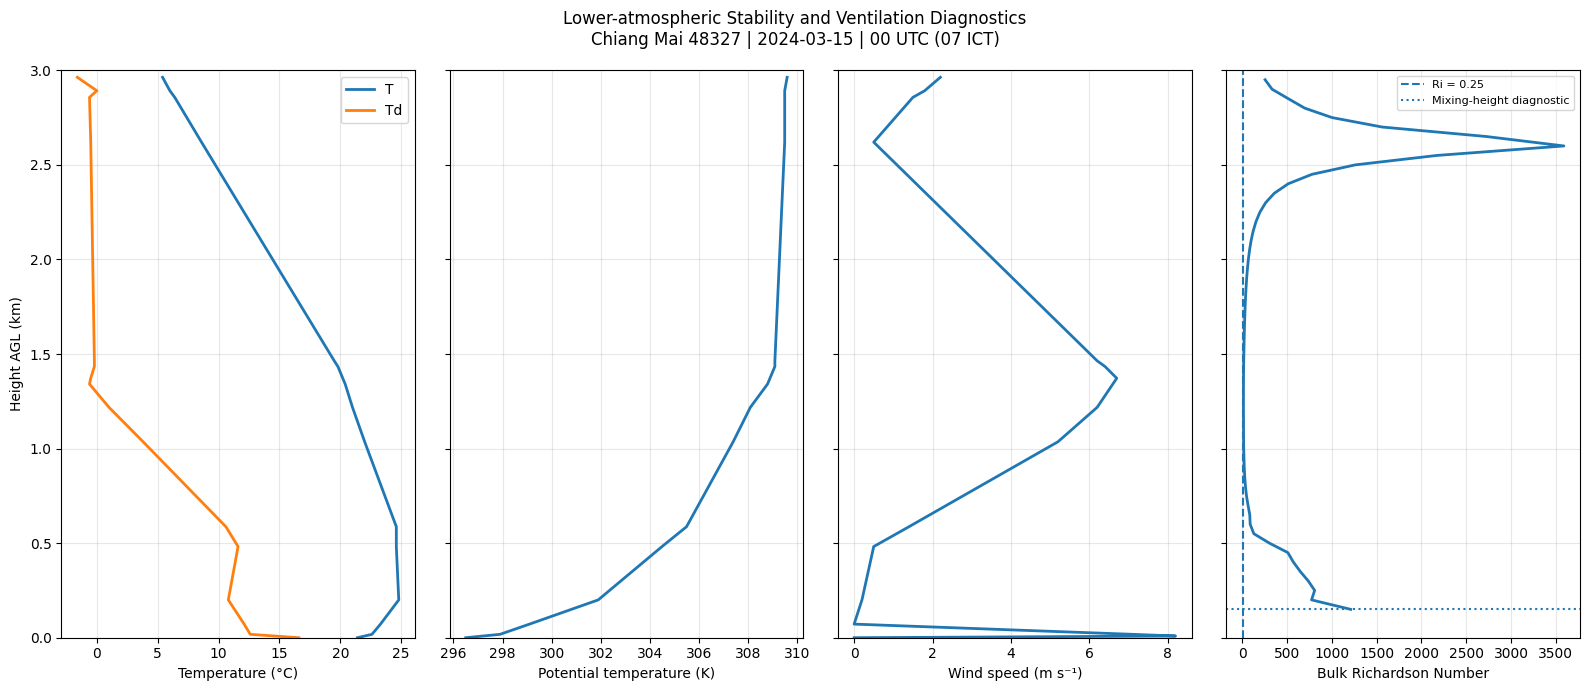

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/04_stability_airpollution_2024-03-15.png


In [15]:
# CELL 15 — Four-panel diagnostic figure
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 7),
    sharey=True
)

z_km = (
    lower["height_agl_m"]
    / 1000
)

axes[0].plot(
    lower["temperature_C"],
    z_km,
    linewidth=2,
    label="T"
)

axes[0].plot(
    lower["dewpoint_C"],
    z_km,
    linewidth=2,
    label="Td"
)

axes[0].set_xlabel(
    "Temperature (°C)"
)

axes[0].set_ylabel(
    "Height AGL (km)"
)

axes[0].legend()

axes[1].plot(
    lower["theta_K"],
    z_km,
    linewidth=2
)

axes[1].set_xlabel(
    "Potential temperature (K)"
)

axes[2].plot(
    lower["wind_speed_ms"],
    z_km,
    linewidth=2
)

axes[2].set_xlabel(
    "Wind speed (m s⁻¹)"
)

axes[3].plot(
    ri_profile["Ri_bulk"],
    ri_profile["height_agl_m"] / 1000,
    linewidth=2
)

axes[3].axvline(
    RI_CRITICAL,
    linestyle="--",
    linewidth=1.5,
    label="Ri = 0.25"
)

if np.isfinite(mixing_height_m):
    axes[3].axhline(
        mixing_height_m / 1000,
        linestyle=":",
        linewidth=1.5,
        label="Mixing-height diagnostic"
    )

axes[3].set_xlabel(
    "Bulk Richardson Number"
)

axes[3].legend(
    fontsize=8
)

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 3)

fig.suptitle(
    f"Lower-atmospheric Stability and Ventilation Diagnostics\n"
    f"Chiang Mai 48327 | {SELECTED_DATE} | 00 UTC (07 ICT)"
)

fig.tight_layout()

SELECTED_FIG = (
    FIG_DIR
    / f"04_stability_airpollution_{SELECTED_DATE}.png"
)

fig.savefig(
    SELECTED_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", SELECTED_FIG)

# 4.12 Batch diagnostics สำหรับ 61 วัน

หนึ่งวันจะสรุป:

### Thermal stability
- lapse rate
- potential-temperature gradient
- mean \(N^2\)

### Inversion
- จำนวน significant inversions
- lowest inversion
- strongest inversion

### Wind
- 0–500 m mean wind
- 0–1 km mean wind

### Air-pollution meteorology
- Ri-based morning mixing-height diagnostic
- mean wind within mixing layer
- ventilation coefficient

In [16]:
# CELL 16 — Robust diagnostic function for one sounding
def analyze_air_pollution_meteorology(
    profile_df,
    grid_step_m=50,
    grid_top_m=3000,
    ri_critical=0.25,
    min_inv_depth_m=100,
    min_inv_delta_t_c=0.5
):
    result = {
        "status": "ok"
    }

    p = (
        profile_df
        .dropna(
            subset=[
                "height_m",
                "temperature_C"
            ]
        )
        .sort_values("height_m")
        .drop_duplicates(subset="height_m")
        .copy()
    )

    if len(p) < 5:
        return {
            "status": "insufficient_levels"
        }

    surface_msl = float(
        p["height_m"].min()
    )

    p["height_agl_m"] = (
        p["height_m"]
        - surface_msl
    )

    p = p[
        (p["height_agl_m"] >= 0)
        & (p["height_agl_m"] <= grid_top_m)
    ].copy()

    if len(p) < 5:
        return {
            "status": "insufficient_lower_levels"
        }

    result["surface_height_m_MSL"] = surface_msl

    result["lapse_0_500_C_per_km"] = environmental_lapse_rate(
        p, 0, 500
    )

    result["lapse_0_1000_C_per_km"] = environmental_lapse_rate(
        p, 0, 1000
    )

    result["lapse_1000_3000_C_per_km"] = environmental_lapse_rate(
        p, 1000, 3000
    )

    result["theta_grad_0_500_K_per_km"] = layer_linear_gradient(
        p, "theta_K", 0, 500
    )

    result["theta_grad_0_1000_K_per_km"] = layer_linear_gradient(
        p, "theta_K", 0, 1000
    )

    reg = interpolate_profile(
        p,
        variables=[
            "temperature_C",
            "theta_K",
            "theta_v_K"
        ],
        step_m=grid_step_m,
        top_m=grid_top_m
    )

    reg["N2_s-2"] = np.nan

    valid_theta = reg["theta_K"].notna()

    if valid_theta.sum() >= 3:
        z = reg.loc[
            valid_theta,
            "height_agl_m"
        ].to_numpy()

        theta = reg.loc[
            valid_theta,
            "theta_K"
        ].to_numpy()

        grad = np.gradient(
            theta,
            z
        )

        reg.loc[
            valid_theta,
            "N2_s-2"
        ] = (
            G
            / theta
            * grad
        )

    result["N2_mean_0_500_s-2"] = layer_mean(
        reg, "N2_s-2", 0, 500
    )

    result["N2_mean_0_1000_s-2"] = layer_mean(
        reg, "N2_s-2", 0, 1000
    )

    inv = detect_inversion_layers(
        reg,
        min_depth_m=min_inv_depth_m,
        min_delta_t_c=min_inv_delta_t_c
    )

    result["n_significant_inversions_0_3km"] = len(inv)

    if len(inv) > 0:

        low = (
            inv
            .sort_values("base_m_AGL")
            .iloc[0]
        )

        strong = (
            inv
            .sort_values(
                "strength_C_per_km",
                ascending=False
            )
            .iloc[0]
        )

        result.update({
            "lowest_inv_base_m_AGL": float(low["base_m_AGL"]),
            "lowest_inv_top_m_AGL": float(low["top_m_AGL"]),
            "lowest_inv_depth_m": float(low["depth_m"]),
            "lowest_inv_deltaT_C": float(low["delta_T_C"]),
            "lowest_inv_strength_C_per_km": float(low["strength_C_per_km"]),
            "strongest_inv_base_m_AGL": float(strong["base_m_AGL"]),
            "strongest_inv_top_m_AGL": float(strong["top_m_AGL"]),
            "strongest_inv_depth_m": float(strong["depth_m"]),
            "strongest_inv_deltaT_C": float(strong["delta_T_C"]),
            "strongest_inv_strength_C_per_km": float(strong["strength_C_per_km"])
        })

    else:

        for name in [
            "lowest_inv_base_m_AGL",
            "lowest_inv_top_m_AGL",
            "lowest_inv_depth_m",
            "lowest_inv_deltaT_C",
            "lowest_inv_strength_C_per_km",
            "strongest_inv_base_m_AGL",
            "strongest_inv_top_m_AGL",
            "strongest_inv_depth_m",
            "strongest_inv_deltaT_C",
            "strongest_inv_strength_C_per_km"
        ]:
            result[name] = np.nan

    puv = add_wind_components(p)

    w500 = mean_layer_wind(
        puv, 0, 500
    )

    w1000 = mean_layer_wind(
        puv, 0, 1000
    )

    result.update({
        "wind_0_500_speed_ms": w500["speed_ms"],
        "wind_0_500_dir_deg": w500["direction_deg"],
        "wind_0_1000_speed_ms": w1000["speed_ms"],
        "wind_0_1000_dir_deg": w1000["direction_deg"]
    })

    ri_regular = interpolate_uv_theta_v(
        p,
        step_m=grid_step_m,
        top_m=grid_top_m
    )

    _, mh = calculate_bulk_richardson(
        ri_regular,
        ri_critical=ri_critical,
        min_height_m=100
    )

    result["mixing_height_Ri_m_AGL"] = mh

    mean_mix_wind = mean_wind_within_height(
        p,
        mh
    )

    result["mean_wind_within_mixing_ms"] = mean_mix_wind

    result["ventilation_coefficient_m2s"] = (
        mh
        * mean_mix_wind
        if (
            np.isfinite(mh)
            and np.isfinite(mean_mix_wind)
        )
        else np.nan
    )

    return result

In [17]:
# CELL 17 — Run all 61 soundings
daily_rows = []

for launch_time, p_day in df.groupby(
    "launch_datetime_utc"
):

    result = analyze_air_pollution_meteorology(
        p_day,
        grid_step_m=GRID_STEP_M,
        grid_top_m=GRID_TOP_M,
        ri_critical=RI_CRITICAL,
        min_inv_depth_m=MIN_INV_DEPTH_M,
        min_inv_delta_t_c=MIN_INV_DELTA_T_C
    )

    result["launch_datetime_utc"] = launch_time
    result["date"] = launch_time.date()
    result["month"] = launch_time.month

    daily_rows.append(result)


airmet_daily = (
    pd.DataFrame(daily_rows)
    .sort_values("launch_datetime_utc")
    .reset_index(drop=True)
)

print("Daily diagnostics:", len(airmet_daily))
print("\nStatus:")

display(
    airmet_daily["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

display(airmet_daily.head(10))

Daily diagnostics: 61

Status:


,status,count
0,ok,61


,status,surface_height_m_MSL,lapse_0_500_C_per_km,lapse_0_1000_C_per_km,lapse_1000_3000_C_per_km,theta_grad_0_500_K_per_km,theta_grad_0_1000_K_per_km,N2_mean_0_500_s-2,N2_mean_0_1000_s-2,n_significant_inversions_0_3km,...,wind_0_500_speed_ms,wind_0_500_dir_deg,wind_0_1000_speed_ms,wind_0_1000_dir_deg,mixing_height_Ri_m_AGL,mean_wind_within_mixing_ms,ventilation_coefficient_m2s,launch_datetime_utc,date,month
0,ok,314.0,-7.474804,-4.086343,6.642027,17.367352,14.054374,0.000562,0.000433,1,...,0.000000,180.000000,0.000000,180.000000,NaN,NaN,NaN,2024-03-01,2024-03-01,3
1,ok,314.0,-4.357400,3.536972,3.086204,21.552091,8.701803,0.000913,0.000492,1,...,0.691368,266.180727,1.026774,261.284679,100.0,1.127069,112.706854,2024-03-02,2024-03-02,3
2,ok,314.0,-1.158393,4.642677,4.106443,18.260371,7.576325,0.000816,0.000445,1,...,2.027160,268.917026,2.681479,258.973499,100.0,1.419295,141.929464,2024-03-03,2024-03-03,3
3,ok,314.0,-3.863754,3.847388,3.325545,22.046842,8.246198,0.000855,0.000460,1,...,1.492784,0.400255,1.453452,323.803318,100.0,1.420389,142.038926,2024-03-04,2024-03-04,3
4,ok,314.0,-4.938163,4.039599,3.326246,22.842152,8.752981,0.000934,0.000502,1,...,0.490466,83.010981,0.249627,50.521488,100.0,0.620671,62.067125,2024-03-05,2024-03-05,3
5,ok,314.0,-11.748736,-0.222107,5.445595,21.695634,10.080004,0.000669,0.000394,2,...,3.512284,1.105124,3.909909,0.812216,100.0,4.429143,442.914266,2024-03-06,2024-03-06,3
6,ok,314.0,-9.753473,-9.753473,5.678311,19.808526,19.808526,0.000607,0.000410,2,...,2.247209,13.303248,2.247209,13.303248,100.0,3.589453,358.945328,2024-03-07,2024-03-07,3
7,ok,314.0,-5.681166,-0.895423,8.479814,15.755871,10.839104,0.000503,0.000381,1,...,2.126886,260.968236,2.067883,259.513358,150.0,4.389591,658.438668,2024-03-08,2024-03-08,3
8,ok,314.0,-5.983818,-1.718324,7.254895,15.873782,11.544280,0.000632,0.000397,1,...,0.814433,338.228491,1.377199,279.625512,100.0,2.066084,206.608351,2024-03-09,2024-03-09,3
9,ok,314.0,-3.769124,-3.769124,7.294061,13.860511,13.860511,0.000418,0.000269,1,...,2.420284,21.621189,2.420284,21.621189,100.0,4.910773,491.077250,2024-03-10,2024-03-10,3


# 4.13 QC ของ Derived Diagnostics

ก่อนทำสถิติ ต้องตรวจ missing values และ range ของตัวแปรที่คำนวณขึ้นใหม่

หากพบค่าผิดปกติ ควรย้อนกลับไปดู vertical profile ของวันนั้นก่อนลบทิ้ง

In [18]:
# CELL 18 — Derived diagnostics QC
important_variables = [
    "lapse_0_500_C_per_km",
    "theta_grad_0_500_K_per_km",
    "N2_mean_0_500_s-2",
    "n_significant_inversions_0_3km",
    "lowest_inv_base_m_AGL",
    "lowest_inv_strength_C_per_km",
    "wind_0_500_speed_ms",
    "wind_0_1000_speed_ms",
    "mixing_height_Ri_m_AGL",
    "mean_wind_within_mixing_ms",
    "ventilation_coefficient_m2s"
]

derived_missing = pd.DataFrame({
    "variable": important_variables,
    "missing_n": [
        airmet_daily[col].isna().sum()
        for col in important_variables
    ],
    "missing_pct": [
        100
        * airmet_daily[col].isna().mean()
        for col in important_variables
    ]
})

display(derived_missing)

print("\nDescriptive statistics:")

display(
    airmet_daily[
        important_variables
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90
        ]
    )
    .T
)

,variable,missing_n,missing_pct
0,lapse_0_500_C_per_km,0,0.000000
1,theta_grad_0_500_K_per_km,0,0.000000
2,N2_mean_0_500_s-2,0,0.000000
3,n_significant_inversions_0_3km,0,0.000000
4,lowest_inv_base_m_AGL,11,18.032787
5,lowest_inv_strength_C_per_km,11,18.032787
6,wind_0_500_speed_ms,0,0.000000
7,wind_0_1000_speed_ms,0,0.000000
8,mixing_height_Ri_m_AGL,1,1.639344
9,mean_wind_within_mixing_ms,1,1.639344



Descriptive statistics:


,count,mean,std,min,10%,25%,50%,75%,90%,max
lapse_0_500_C_per_km,61.0,-3.119762,5.025214,-26.813024,-7.522184,-5.904386,-2.794975,0.083683,3.074812,4.703189
theta_grad_0_500_K_per_km,61.0,13.494121,5.483789,5.060284,6.608364,9.866485,12.833150,16.162265,20.502698,36.646933
N2_mean_0_500_s-2,61.0,0.000449,0.000170,0.000179,0.000248,0.000317,0.000442,0.000528,0.000632,0.000934
n_significant_inversions_0_3km,61.0,0.934426,0.543717,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2.000000
lowest_inv_base_m_AGL,50.0,54.000000,249.047164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1600.000000
lowest_inv_strength_C_per_km,50.0,12.098363,6.641816,3.000000,4.413121,6.818649,11.315642,15.515518,21.987622,31.723046
wind_0_500_speed_ms,61.0,2.557588,1.744904,0.000000,0.675911,1.570411,2.336641,3.246967,4.460773,9.760282
wind_0_1000_speed_ms,61.0,2.439826,1.549763,0.000000,0.819881,1.668646,2.309565,2.734658,4.127781,9.760282
mixing_height_Ri_m_AGL,60.0,127.500000,51.605577,100.000000,100.000000,100.000000,100.000000,150.000000,200.000000,300.000000
mean_wind_within_mixing_ms,60.0,4.213029,2.711051,0.000000,1.265721,3.071420,3.926517,4.948975,6.137574,15.422753


# 4.14 Inversion Frequency

เราจะถามว่า:

> March–April 2024 มี significant inversion ใน 0–3 km AGL กี่วัน?

ต้องจำว่า frequency นี้ขึ้นกับ algorithm และ threshold ที่กำหนด

In [19]:
# CELL 19 — Inversion occurrence
airmet_daily["has_significant_inversion"] = (
    airmet_daily[
        "n_significant_inversions_0_3km"
    ]
    .fillna(0)
    > 0
)

n_inv_days = int(
    airmet_daily[
        "has_significant_inversion"
    ].sum()
)

n_total_days = len(
    airmet_daily
)

inv_frequency_pct = (
    100
    * n_inv_days
    / n_total_days
)

print(
    "Days with significant inversion:",
    n_inv_days,
    "/",
    n_total_days
)

print(
    "Inversion frequency:",
    round(
        inv_frequency_pct,
        1
    ),
    "%"
)

display(
    pd.crosstab(
        airmet_daily["month"],
        airmet_daily["has_significant_inversion"],
        margins=True
    )
)

Days with significant inversion: 50 / 61
Inversion frequency: 82.0 %


has_significant_inversion,False,True,All
month,,,
3,2,29,31
4,9,21,30
All,11,50,61


# 4.15 Time Series: Mixing Height และ Ventilation

กราฟนี้ใช้สำรวจ temporal variability เท่านั้น

ยังไม่ควรสรุป causal relationship กับ PM₂.₅ เพราะยังไม่ได้รวม pollutant concentration และ emissions

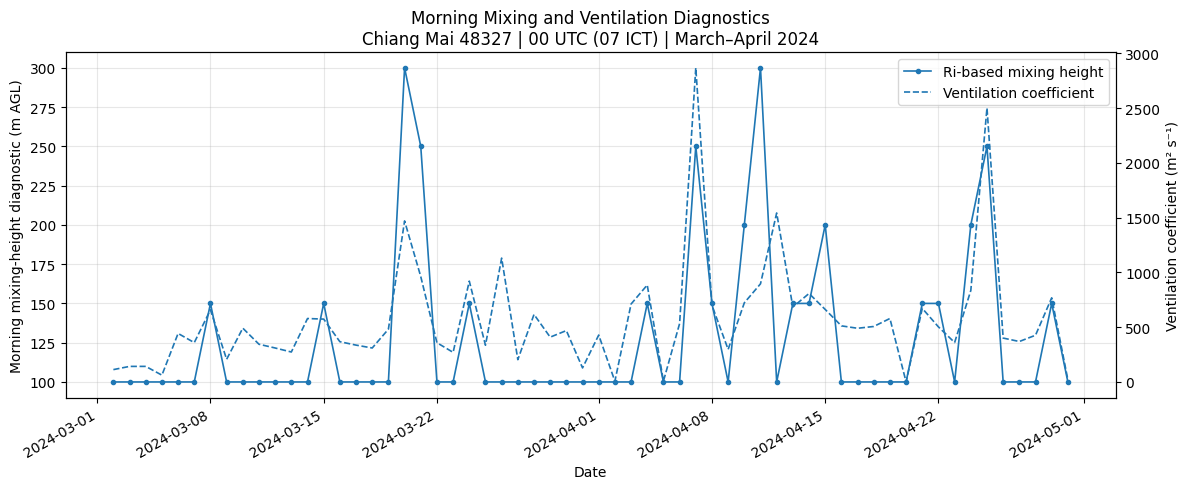

Saved: /content/drive/MyDrive/Teaching_Sounding_AirQuality/04_figures/04_mixing_height_ventilation_MarApr2024.png


In [20]:
# CELL 20 — Time series
dates = pd.to_datetime(
    airmet_daily["date"]
)

fig, ax1 = plt.subplots(
    figsize=(12, 5)
)

line1 = ax1.plot(
    dates,
    airmet_daily[
        "mixing_height_Ri_m_AGL"
    ],
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="Ri-based mixing height"
)

ax1.set_xlabel("Date")
ax1.set_ylabel(
    "Morning mixing-height diagnostic (m AGL)"
)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

line2 = ax2.plot(
    dates,
    airmet_daily[
        "ventilation_coefficient_m2s"
    ],
    linewidth=1.2,
    linestyle="--",
    label="Ventilation coefficient"
)

ax2.set_ylabel(
    "Ventilation coefficient (m² s⁻¹)"
)

lines = line1 + line2

labels = [
    line.get_label()
    for line in lines
]

ax1.legend(
    lines,
    labels,
    loc="best"
)

ax1.set_title(
    "Morning Mixing and Ventilation Diagnostics\n"
    "Chiang Mai 48327 | 00 UTC (07 ICT) | March–April 2024"
)

fig.autofmt_xdate()
fig.tight_layout()

TIME_FIG = (
    FIG_DIR
    / "04_mixing_height_ventilation_MarApr2024.png"
)

fig.savefig(
    TIME_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", TIME_FIG)

# 4.16 การตีความเชิงคุณภาพอากาศ

จาก sounding เราสามารถกล่าวได้ว่า:

> บางวันมี meteorological conditions ที่เอื้อต่อการระบายตัวต่ำ เช่น stable lower atmosphere, shallow mixing-height diagnostic และ weak wind

แต่ยังไม่ควรกล่าวว่า:

> “PM₂.₅ สูงเพราะ inversion”

จนกว่าจะรวมข้อมูลเพิ่มเติม เช่น

- PM₂.₅ concentration
- emissions/activity
- surface meteorology
- regional transport
- biomass-burning/hotspot
- precipitation/deposition

นี่คือความแตกต่างระหว่าง

\[
meteorological\ favorability
\]

กับ

\[
observed\ pollutant\ concentration
\]

In [21]:
# CELL 21 — Save outputs
AIR_MET_FILE = (
    OUTPUT_DIR
    / "04_daily_airpollution_meteorology_48327_00UTC_MarApr2024.csv"
)

INVERSION_FILE = (
    OUTPUT_DIR
    / f"04_inversion_layers_{SELECTED_DATE}.csv"
)

DERIVED_QC_FILE = (
    OUTPUT_DIR
    / "04_derived_diagnostics_missing_summary.csv"
)

airmet_daily.to_csv(
    AIR_MET_FILE,
    index=False
)

inversions.to_csv(
    INVERSION_FILE,
    index=False
)

derived_missing.to_csv(
    DERIVED_QC_FILE,
    index=False
)

print("Saved:")
print(" -", AIR_MET_FILE)
print(" -", INVERSION_FILE)
print(" -", DERIVED_QC_FILE)
print("\nDaily rows:", len(airmet_daily))

Saved:
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/04_daily_airpollution_meteorology_48327_00UTC_MarApr2024.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/04_inversion_layers_2024-03-15.csv
 - /content/drive/MyDrive/Teaching_Sounding_AirQuality/03_output/04_derived_diagnostics_missing_summary.csv

Daily rows: 61


# 4.17 แบบฝึกหัด

## Exercise 1 — Lapse Rate
เลือก 3 วัน แล้วเปรียบเทียบ 0–500 m lapse rate, 0–1 km lapse rate และ potential-temperature gradient

## Exercise 2 — Inversion Threshold Sensitivity
เปลี่ยน

```python
MIN_INV_DEPTH_M = 100
MIN_INV_DELTA_T_C = 0.5
```

เป็น

```python
MIN_INV_DEPTH_M = 200
MIN_INV_DELTA_T_C = 1.0
```

แล้วดู inversion frequency เปลี่ยนอย่างไร

## Exercise 3 — Bulk Richardson Threshold
ทดลอง `RI_CRITICAL = 0.20`, `0.25`, `0.30` แล้วเปรียบเทียบ mixing-height diagnostic

## Exercise 4 — Ventilation
เลือกวัน ventilation coefficient ต่ำและสูงอย่างละ 2 วัน แล้วดู theta profile, wind profile และ inversion

## Exercise 5 — Scientific Interpretation
ตอบว่า หากวันหนึ่งมี inversion ต่ำและ ventilation coefficient ต่ำ เราสรุปได้หรือไม่ว่า PM₂.₅ ต้องสูง พร้อมอธิบายบทบาทของ emissions, transport, deposition, chemistry และ precipitation

---

# สรุป Notebook 04

1. MSL และ AGL เป็น vertical references ต่างกัน
2. lapse rate ใช้ดูการเปลี่ยนอุณหภูมิกับความสูง
3. potential-temperature gradient ใช้พิจารณา static stability
4. inversion คือชั้นที่ \(dT/dz>0\)
5. inversion ควรอธิบายทั้ง base, top, depth และ strength
6. \(N^2\) เป็น quantitative stability measure
7. wind direction ควรถูกแปลงเป็น \(u,v\) ก่อน averaging
8. Bulk Richardson Number เป็น diagnostic ที่รวม buoyancy และ shear
9. mixing height จาก Ri เป็น **diagnostic estimate**
10. ventilation coefficient รวม mixing depth กับ wind
11. meteorology อาจเอื้อต่อ pollutant accumulation แต่ไม่ใช่หลักฐานเพียงพอว่าความเข้มข้นต้องสูง
12. 00 UTC ของเชียงใหม่สะท้อน **morning atmosphere at ~07:00 ICT**

## Notebook ต่อไป

`05_temporal_statistics_MarApr2024.ipynb`

จะรวมผลจาก Notebook 03 และ 04 เพื่อทำ:

- descriptive statistics
- median / IQR / percentiles
- March vs April
- time series และ rolling mean
- boxplot / ECDF
- Welch's t-test
- Mann–Whitney U
- Spearman correlation
- correlation matrix
- การตีความ statistical significance
- ข้อจำกัดจาก temporal autocorrelation